# Тест расчета матрицы прибытия с учетом имеющихся подразделений

Основная идея: Перед расчетом матрицы определить какие зданий прикрыты имеющимися подразделениями и использовать только их.

In [1]:
import osmnx as ox
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

import genesis as genesis


# Версии библиотек
print('OSMnx:', ox.__version__,
      '\nGeoPandas:', gpd.__version__,
      '\nPandas:', pd.__version__,
      '\ngenesis:', genesis.__version__,
      )

OSMnx: 2.0.1 
GeoPandas: 1.0.1 
Pandas: 2.2.2 
genesis: 0.2.200


In [4]:
DATA_NODE_FIELD     = 'node'
UNITS_NAME_FIELD    = 'name'
# Для графа:
EDGES_WEIGHT_FIELD  = 'travel_time'
## Для матрицы прибытия:
DATA_SAMPLE_SIZE    = None
DATA_CUTOFF_FIELD   = None
# TARGET_SET          = None

## Для ADD:
NAMES_PATTERN       = '{}'
START_NAMES_INDEX   = 1

# Загрузка данных

In [40]:
from genesis.states import FirstArrivalUnitState
from graphs.speeds import set_graph_travel_times, kmh_to_mm
from fire_units.settings import DEFAULT_SPEEDS


# map_path = 'C:/Users/Obsidian/Desktop/Красноярск Демо/'
map_path = 'G:/QGIS/_Красноярск ДИССЕРТАЦИЯ/'

# 1. Загрузка исходных данных
## Загрузка ГДС
G = ox.load_graphml(f'{map_path}fire_data/rng.ml')
## Установка скоростного режима
set_graph_travel_times(G, DEFAULT_SPEEDS, kmh_to_mm)

## Загрузка зданий
buildings = gpd.read_file(f'{map_path}data/bld.gpkg')
### Сопоставление зданий с ближайшими узлами ГДС
centroids = ox.projection.project_gdf(buildings).geometry.centroid
buildings['node'] = ox.distance.nearest_nodes(ox.project_graph(G), 
                                              centroids.x,
                                              centroids.y
                                              )

## Загрузка подразделений
existed_units = gpd.read_file(f'{map_path}fire_data/units.gpkg')
### Сопоставление зданий с ближайшими узлами ГДС
centroids = ox.projection.project_gdf(existed_units).geometry.centroid
existed_units['node'] = ox.distance.nearest_nodes(ox.project_graph(G), 
                                              centroids.x,
                                              centroids.y
                                              )
existed_units_dict = {node:name for node, name in zip(existed_units['node'], existed_units['name'])}

g:\GitRepositories\_Dislocation\genesis\work\genesis\graphs\speeds.py:110: UserWarning: Граф был ранее упрощен! Оценка времени следования такого графа может повлечь неточности. Рекомендуется устанавливать время следования для неупрощенного графа и только после этого упрощать
  warnings.warn("Граф был ранее упрощен! Оценка времени следования такого графа может повлечь неточности. " + \


In [ ]:
# Для скорости расчета оставим только часть исходных зданий
buildings = buildings.sample(20_000)

### Расчет без отброса прикрытых существующими подразделениями зданий

In [ ]:
from genesis.states import FirstArrivalUnitState, get_atm

# Случайный выбор
target_layer_gdf = buildings.sample(1000)


matrix = get_atm(G,
    data              = target_layer_gdf,
    cutoff            = 10,
    )

|########################################| 100.0%


In [ ]:
# 3. Сборка решения
# ================================================================================================
## Выбор метрики
from genesis.lscp import LSCP_ADD
from fire_units.metrics import CoverIndexBuildingADD
from fire_units.settings import DEFAULT_SPEEDS
from genesis.lscp import LSCP_ADD

from graphs.speeds import kmh_to_mm, set_graph_travel_times

cutoff = 10
target_set = None
target_metric = 1  # 0 - по кол-ву подразделений, 1 - по ИП 
target_value = 95  # значение для остановки расчета


# Используем только отобранные здания
metric_func  = CoverIndexBuildingADD(target_layer_gdf, ip_val=cutoff)

## Функция обратного вызова при расчете подразделений
def after_mclp_function(best_metric, dynamic_nodes, **kwargs):
    metric = round(best_metric, 2)
    print(f'Подразделений: {len(dynamic_nodes)}, Метрика: {metric}')

## Функция остановки
def stop_case (value, dynamic_nodes, **kwargs):
    if target_metric == 0:
        return len(dynamic_nodes) >= target_value
    elif target_metric == 1:
        return value >= target_value


## Сборка и инициализация алгоритма ADD
add = LSCP_ADD(  
    state_function      = FirstArrivalUnitState(),
    matrix              = matrix,
    metric_function     = metric_func,
    ip_val              = cutoff,
    stop_case_function  = stop_case,
    names_pattern       = NAMES_PATTERN,
    start_names_index   = START_NAMES_INDEX,
    after_mclp_function = after_mclp_function,
    check_for_best_time = True,
)

# 4. Расчет
# ================================================================================================
best_nodes, best_metric = add(
    env           = G,
    dynamic_nodes = None,
    static_nodes  = existed_units_dict,
    # area          = points_mask,
)

### Расчет с учетом отброса прикрытых существующими подразделениями зданий

In [41]:
try:
    buildings.drop('times', inplace=True, axis=1)
except:
    print('Отброс не требуется')

Отброс не требуется


In [42]:
# Выбор исходя из достижимости подразделений
times, nearest = FirstArrivalUnitState()(G, existed_units_dict)

# Объединение зданий и времени прибытия
buildings = pd.merge(buildings,
                    times,
                    how='left',
                    left_on='node',
                    right_index=True)
buildings.rename(columns={'times': 'arrival_time'}, inplace=True)
print('Всего зданий', len(buildings))

# отброс зданий со временем прибытия минее 10 минут (прикрытых)
target_layer_gdf = buildings.query('arrival_time>10')
print('Зданий прикрыто', len(target_layer_gdf))

Всего зданий 58094
Зданий прикрыто 16610


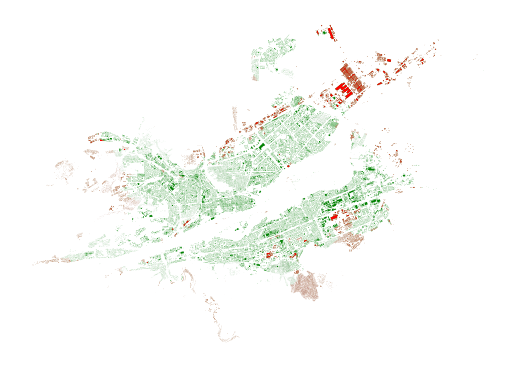

In [43]:
ax = buildings.plot(color='g')
target_layer_gdf.plot(ax=ax, color='r')
ax.axis('off');

In [44]:
matrix = get_atm(G,
    data              = target_layer_gdf,
    cutoff            = 10,
    )

|########################################| 100.0%


In [45]:
# 3. Сборка решения
# ================================================================================================
## Выбор метрики
from genesis.lscp import LSCP_ADD
from fire_units.metrics import CoverIndexBuildingADD
from fire_units.settings import DEFAULT_SPEEDS
from genesis.lscp import LSCP_ADD


cutoff = 10
target_set = None
target_metric = 1  # 0 - по кол-ву подразделений, 1 - по ИП 
target_value = 95  # значение для остановки расчета



# Используем все здания
metric_func  = CoverIndexBuildingADD(buildings, ip_val=cutoff)

## Функция обратного вызова при расчете подразделений
def after_mclp_function(best_metric, dynamic_nodes, **kwargs):
    metric = round(best_metric, 2)
    print(f'Подразделений: {len(dynamic_nodes)}, Метрика: {metric}')

## Функция остановки
def stop_case (value, dynamic_nodes, **kwargs):
    if target_metric == 0:
        return len(dynamic_nodes) >= target_value
    elif target_metric == 1:
        return value >= target_value


## Сборка и инициализация алгоритма ADD
add = LSCP_ADD(  
    state_function      = FirstArrivalUnitState(),
    matrix              = matrix,
    metric_function     = metric_func,
    ip_val              = cutoff,
    stop_case_function  = stop_case,
    names_pattern       = NAMES_PATTERN,
    start_names_index   = START_NAMES_INDEX,
    after_mclp_function = after_mclp_function,
    check_for_best_time = True,
)

# 4. Расчет
# ================================================================================================
best_nodes, best_metric = add(
    env           = G,
    dynamic_nodes = None,
    static_nodes  = existed_units_dict,
    # area          = points_mask,
)

KeyError: "None of [Index([3272174721, 3285364967, 6832062973, 4100024727, 2964206956, 7863477991,\n       4082373816, 7027868615, 6468642582, 6017415936, 6975650554, 6225811246],\n      dtype='int64')] are in the [columns]"